# Phase 5C — Candidate Algorithm Testing (Small Subset)

Run all 4 centerline-generation candidates on a **small spatial clip** of VPD data,
evaluate each with the Phase 5A metrics harness, and compare side-by-side.

| # | Candidate | Key Idea |
|---|-----------|----------|
| 1 | KDE Skeleton | Rasterize → blur → threshold → skeletonize → vectorize |
| 2 | DBSCAN Polyline | Densify to points, cluster (x,y,heading), PCA-sort |
| 3 | Trace Clustering | O(n²) Hausdorff distance matrix → DBSCAN → medoid |
| 4 | Incremental Graph | Longest-first, skip redundant, union + linemerge |

In [ ]:
import sys, os, time, warnings, importlib, gc
warnings.filterwarnings('ignore')

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
if not os.path.isdir(os.path.join(PROJECT_ROOT, 'src')):
    PROJECT_ROOT = os.getcwd()
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)
os.chdir(PROJECT_ROOT)

import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import box, LineString
import logging, traceback

logging.basicConfig(level=logging.INFO, format='%(asctime)s %(name)-25s %(levelname)-5s %(message)s')
logger = logging.getLogger('nb03')

# Force-reload to pick up latest code (including VPD loader optimisations)
import src.loaders.vpd_loader   as _vpd_mod;  importlib.reload(_vpd_mod)
import src.algorithms.candidates as _cand_mod; importlib.reload(_cand_mod)
import src.evaluation.metrics   as _met_mod;  importlib.reload(_met_mod)

from src.config import BBOX, CRS, OUTPUTS_DIR
from src.loaders.vpd_loader import load_vpd
from src.loaders import load_nav_streets
from src.evaluation.metrics import (
    evaluate_centerlines, print_metrics, metrics_to_dict, METRIC_CRS
)
from src.algorithms.candidates import (
    candidate_kde_skeleton,
    candidate_dbscan_polyline,
    candidate_trace_clustering,
    candidate_incremental_graph,
)

FIGURES_DIR = OUTPUTS_DIR / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print(f'Working dir : {os.getcwd()}')
print(f'Full BBOX   : {BBOX}')
print(f'Metric CRS  : {METRIC_CRS}')

Working dir : e:\Coding projects\HERE-Geospatial-Hackathon
Full BBOX   : (21.088588, 42.571255, 21.188588, 42.671255)
Metric CRS  : EPSG:32634


## 1 — Load data (memory-optimised: overlap-only VPD)

Nav Streets (our ground truth / reference) only covers ~30% of the study BBOX.
We **load Nav Streets first** to compute the overlap region, then pass that
tight bbox directly to `load_vpd()` so it pre-filters rows **during chunk
reading** (before WKT parsing).  This cuts RAM from ~14 GB to ~2–3 GB.

In [ ]:
import gc

# ── Step 1: Load Nav Streets (small, fast) to find its spatial extent ──
t0 = time.time()
print('Loading Nav Streets …')
nav_gdf = load_nav_streets()
print(f'  Nav Streets: {len(nav_gdf)} links')

# ── Step 2: Compute the tight overlap BBOX ─────────────────────────────
nav_bounds = nav_gdf.total_bounds  # minx, miny, maxx, maxy

CLIP_BBOX = (
    BBOX[0],                     # min_x from study BBOX
    BBOX[1],                     # min_y from study BBOX
    float(nav_bounds[2]),        # max_x from Nav Streets
    float(nav_bounds[3]),        # max_y from Nav Streets
)

print(f'Study BBOX     : {BBOX}')
print(f'Nav GT extent  : {tuple(nav_bounds)}')
print(f'Overlap CLIP   : {CLIP_BBOX}')

# ── Step 3: Load VPD — only the overlap region ─────────────────────────
#   The loader pre-filters raw WKT strings by bbox BEFORE parsing geometry.
#   This avoids loading the entire ~4 GB file into RAM.
print(f'\nLoading VPD (overlap-only, bbox={CLIP_BBOX}) …')
vpd_clip = load_vpd(
    bbox=CLIP_BBOX,           # tight overlap bbox → fast pre-filter
    clip_to_bbox=True,        # precise spatial clip after geometry parsing
    fused_only=True,          # keep only fused == 'Yes'
    drop_altitudes=True,      # we don't need altitudes → save RAM
)
gc.collect()

# ── Step 4: Clip Nav Streets to same overlap region ────────────────────
clip_box = box(*CLIP_BBOX)
nav_clip = nav_gdf[nav_gdf.intersects(clip_box)].copy()
del nav_gdf  # free the full Nav Streets from memory
gc.collect()

elapsed = time.time() - t0
print(f'\nVPD in overlap : {len(vpd_clip)} fused traces')
print(f'Nav in overlap : {len(nav_clip)} links')
print(f'Total load time: {elapsed:.1f}s')

if len(vpd_clip) == 0:
    raise RuntimeError('VPD clip is empty — check CLIP_BBOX')

2026-02-10 20:18:41,917 src.loaders.nav_loader    INFO  Loading Nav Streets from E:\Coding projects\HERE-Geospatial-Hackathon\data\Kosovo_s_nav_streets\Kosovo.gpkg…


Loading Nav Streets …


2026-02-10 20:18:42,270 src.loaders.nav_loader    INFO  Bbox clip: 4353 → 1250 road links.
2026-02-10 20:18:42,277 src.loaders.nav_loader    INFO  Nav Streets loaded: 1250 road links, 14 columns.
2026-02-10 20:18:42,277 src.loaders.vpd_loader    INFO  Loading VPD from E:\Coding projects\HERE-Geospatial-Hackathon\data\Kosovo_VPD\Kosovo_VPD.csv (chunk_size=10000)…


  Nav Streets: 1250 links
Loading VPD (takes ~9 min) …


2026-02-10 20:19:07,085 src.loaders.vpd_loader    INFO  Read 54542 rows total, kept 54542 fused rows.
2026-02-10 20:19:07,112 src.loaders.vpd_loader    INFO  Parsing WKT geometries…
2026-02-10 20:26:07,231 src.loaders.vpd_loader    INFO  Bbox clip: 54542 → 54542 rows.
2026-02-10 20:26:07,256 src.loaders.vpd_loader    INFO  VPD loaded: 54542 rows, 13 columns.


  VPD total : 54542 rows
Loaded in 446.4s


VPD clip length : 60949.2 km
Nav clip length : 161.7 km


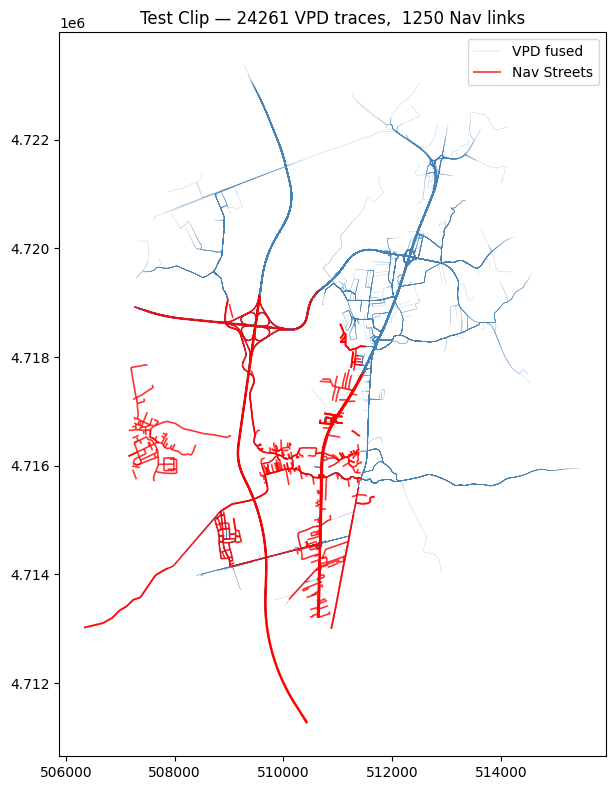

In [ ]:
# ── Project to metric CRS (EPSG:32634) ───────────────────────────────
vpd_m  = vpd_clip.to_crs(METRIC_CRS)
nav_m  = nav_clip.to_crs(METRIC_CRS)

# Free WGS84 copies — we only need metric from here on
del vpd_clip, nav_clip
gc.collect()

total_vpd_length_km = vpd_m.geometry.length.sum() / 1000
total_nav_length_km = nav_m.geometry.length.sum() / 1000
print(f'VPD clip length : {total_vpd_length_km:.1f} km')
print(f'Nav clip length : {total_nav_length_km:.1f} km')
print(f'VPD traces      : {len(vpd_m)}')
print(f'Nav links       : {len(nav_m)}')

# Quick visual
fig, ax = plt.subplots(figsize=(8, 8))
vpd_m.plot(ax=ax, color='steelblue', linewidth=0.3, alpha=0.4, label='VPD fused')
nav_m.plot(ax=ax, color='red',       linewidth=1.2, alpha=0.8, label='Nav Streets')
ax.set_title(f'Test Clip — {len(vpd_m)} VPD traces,  {len(nav_m)} Nav links')
ax.legend(); ax.set_aspect('equal')
plt.tight_layout()
plt.show()

## 2 — Run all 4 candidates

In [ ]:
# ── Run each candidate, collect results + wall-clock time ─────────────
# Subsampling for O(n²) algorithms is now handled INSIDE each function.

candidates = {
    'KDE Skeleton':       (candidate_kde_skeleton,       {'pixel_size': 2.0, 'blur_sigma': 3.0, 'threshold': 0.15}),
    'DBSCAN Polyline':    (candidate_dbscan_polyline,    {'eps': 12.0, 'min_samples': 4, 'heading_weight': 1.0}),
    'Trace Clustering':   (candidate_trace_clustering,   {'eps': 20.0, 'min_samples': 2, 'max_traces': 400}),
    'Incremental Graph':  (candidate_incremental_graph,  {'buffer_dist': 8.0, 'snap_dist': 5.0}),
}

results = {}  # name → {'gdf': GeoDataFrame, 'time_s': float, 'n_input': int}

for name, (func, kwargs) in candidates.items():
    print(f'\n{"═"*60}')
    print(f'Running: {name}')
    print(f'  params: {kwargs}')

    t0 = time.time()
    try:
        gdf_out = func(vpd_m, **kwargs)
        elapsed = time.time() - t0
        n_lines = len(gdf_out)
        total_km = gdf_out.geometry.length.sum() / 1000 if n_lines > 0 else 0
        print(f'  ✓ {n_lines} lines, {total_km:.2f} km in {elapsed:.1f}s')
        results[name] = {'gdf': gdf_out, 'time_s': elapsed, 'n_input': len(vpd_m)}
    except Exception as e:
        elapsed = time.time() - t0
        print(f'  ✗ FAILED after {elapsed:.1f}s: {e}')
        traceback.print_exc()
        results[name] = {'gdf': gpd.GeoDataFrame(geometry=[], crs=METRIC_CRS), 'time_s': elapsed, 'n_input': len(vpd_m)}
    finally:
        gc.collect()  # reclaim memory between candidates

print(f'\n{"═"*60}')
print('All candidates finished.')


════════════════════════════════════════════════════════════
Running: KDE Skeleton
  params: {'pixel_size': 2.0, 'blur_sigma': 3.0, 'threshold': 0.15}
  ✓ 21 lines, 10.46 km in 423.0s

════════════════════════════════════════════════════════════
Running: DBSCAN Polyline
  params: {'eps': 12.0, 'min_samples': 4, 'heading_weight': 1.0}


## 3 — Visual comparison (2 × 2 grid)

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 16), sharex=True, sharey=True)

for ax, (name, res) in zip(axes.ravel(), results.items()):
    gdf_out = res['gdf']
    # Background: Nav Streets in light red
    nav_m.plot(ax=ax, color='red', linewidth=1.0, alpha=0.3, label='Nav Streets')
    # VPD traces in light blue
    vpd_m.plot(ax=ax, color='steelblue', linewidth=0.2, alpha=0.15)
    # Candidate result
    if not gdf_out.empty:
        gdf_out.plot(ax=ax, color='lime', linewidth=1.5, alpha=0.9, label=name)
    n = len(gdf_out)
    km = gdf_out.geometry.length.sum() / 1000 if n else 0
    ax.set_title(f'{name}\n{n} lines · {km:.1f} km · {res["time_s"]:.1f}s', fontsize=11)
    ax.legend(fontsize=8)
    ax.set_aspect('equal')

plt.suptitle('Phase 5C — Candidate Comparison (small clip)', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'phase5c_candidate_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved to {FIGURES_DIR / "phase5c_candidate_comparison.png"}')

## 4 — Evaluate each candidate against Nav Streets

In [ ]:
import pandas as pd

eval_rows = []

for name, res in results.items():
    gdf_out = res['gdf']
    if gdf_out.empty:
        print(f'{name}: EMPTY — skipping evaluation')
        eval_rows.append({'candidate': name, 'status': 'EMPTY'})
        continue

    print(f'\nEvaluating: {name} …')
    t0 = time.time()
    try:
        metrics = evaluate_centerlines(gdf_out, nav_m, buffer_m=15.0)
        elapsed = time.time() - t0
        d = metrics_to_dict(metrics)
        d['candidate'] = name
        d['runtime_s'] = res['time_s']
        d['eval_s'] = elapsed
        eval_rows.append(d)
        print_metrics(metrics)
    except Exception as e:
        print(f'  Evaluation FAILED: {e}')
        traceback.print_exc()
        eval_rows.append({'candidate': name, 'status': f'EVAL_FAIL: {e}'})

# Build comparison DataFrame
df_compare = pd.DataFrame(eval_rows)
print('\n' + '═'*80)
print('COMPARISON TABLE')
print('═'*80)
display(df_compare)

## 5 — Summary & key comparison metrics

In [ ]:
# Highlight the most important metrics side by side
key_cols = ['candidate', 'runtime_s', 'nav_recovery_pct', 'nav_precision_pct',
            'mean_hausdorff_m', 'median_hausdorff_m',
            'mean_angular_deflection_deg', 'num_components',
            'num_dangling_ends', 'total_length_km', 'redundancy_pct']

available = [c for c in key_cols if c in df_compare.columns]
summary = df_compare[available].copy()

print('Key metrics comparison:')
display(summary.style.format(precision=2).highlight_max(
    subset=[c for c in ['nav_recovery_pct', 'nav_precision_pct'] if c in summary.columns],
    color='lightgreen'
).highlight_min(
    subset=[c for c in ['mean_hausdorff_m', 'redundancy_pct', 'num_dangling_ends'] if c in summary.columns],
    color='lightgreen'
))

# Save
summary.to_csv(OUTPUTS_DIR / 'phase5c_candidate_comparison.csv', index=False)
print(f'\nSaved to {OUTPUTS_DIR / "phase5c_candidate_comparison.csv"}')